In [7]:
# ==========================================================
# Install Required Libraries
# ==========================================================

!pip -q install timm

# ==========================================================
# Import Libraries
# ==========================================================

import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# Device Configuration
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("TorchVision Version :", torchvision.__version__)
print("Device :", device)
print("=" * 60)

# ==========================================================
# Reproducibility
# ==========================================================

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

PyTorch Version : 2.11.0+cu128
TorchVision Version : 0.26.0+cu128
Device : cuda


In [8]:
# ==========================================================
# Dataset Paths
# ==========================================================

train_dir = "/content/train"
test_dir = "/content/test"

IMG_SIZE = 224
BATCH_SIZE = 32

# ==========================================================
# Image Transformations
# ==========================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================================================
# Load Dataset
# ==========================================================

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes :", class_names)
print("Number of Classes :", NUM_CLASSES)

print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of Classes : 7
Training Images : 28709
Testing Images : 7178


In [9]:
# ==========================================================
# Build Pretrained Vision Transformer (ViT-B/16)
# ==========================================================

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [11]:
# ==========================================================
# Freeze ViT Backbone
# ==========================================================

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only classification head
for param in model.head.parameters():
    param.requires_grad = True

print("Only Classification Head is Trainable.")

# ==========================================================
# Loss Function
# ==========================================================

criterion = nn.CrossEntropyLoss()

# ==========================================================
# Optimizer
# ==========================================================

optimizer = optim.Adam(
    model.head.parameters(),
    lr=1e-3
)

# ==========================================================
# Learning Rate Scheduler
# ==========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

# ==========================================================
# Training Function
# ==========================================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds==labels).sum().item()

    loss = running_loss/len(loader)
    acc = correct/total

    return loss, acc


# ==========================================================
# Validation Function
# ==========================================================

def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            total += labels.size(0)
            correct += (preds==labels).sum().item()

    loss = running_loss/len(loader)
    acc = correct/total

    return loss, acc

Only Classification Head is Trainable.


In [12]:
# ==========================================================
# Train Classification Head
# ==========================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        test_loader
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/5] | Train Loss: 1.2756 | Train Acc: 0.5217 | Val Loss: 1.2019 | Val Acc: 0.5541
Epoch [2/5] | Train Loss: 1.1716 | Train Acc: 0.5633 | Val Loss: 1.1741 | Val Acc: 0.5619
Epoch [3/5] | Train Loss: 1.1393 | Train Acc: 0.5745 | Val Loss: 1.1866 | Val Acc: 0.5589
Epoch [4/5] | Train Loss: 1.1280 | Train Acc: 0.5794 | Val Loss: 1.1565 | Val Acc: 0.5748
Epoch [5/5] | Train Loss: 1.1159 | Train Acc: 0.5881 | Val Loss: 1.2032 | Val Acc: 0.5563


In [28]:
# ==========================================================
# Model Evaluation
# ==========================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred,average="weighted")
recall = recall_score(y_true,y_pred,average="weighted")
f1 = f1_score(y_true,y_pred,average="weighted")

print("="*50)
print("Vision Transformer Performance")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Vision Transformer Performance
Accuracy  : 0.6199
Precision : 0.6123
Recall    : 0.6199
F1 Score  : 0.6117

Classification Report

              precision    recall  f1-score   support

       angry       0.51      0.55      0.53       958
     disgust       0.53      0.43      0.48       111
        fear       0.47      0.38      0.42      1024
       happy       0.74      0.91      0.82      1774
     neutral       0.59      0.60      0.59      1233
         sad       0.53      0.47      0.50      1247
    surprise       0.81      0.65      0.72       831

    accuracy                           0.62      7178
   macro avg       0.60      0.57      0.58      7178
weighted avg       0.61      0.62      0.61      7178



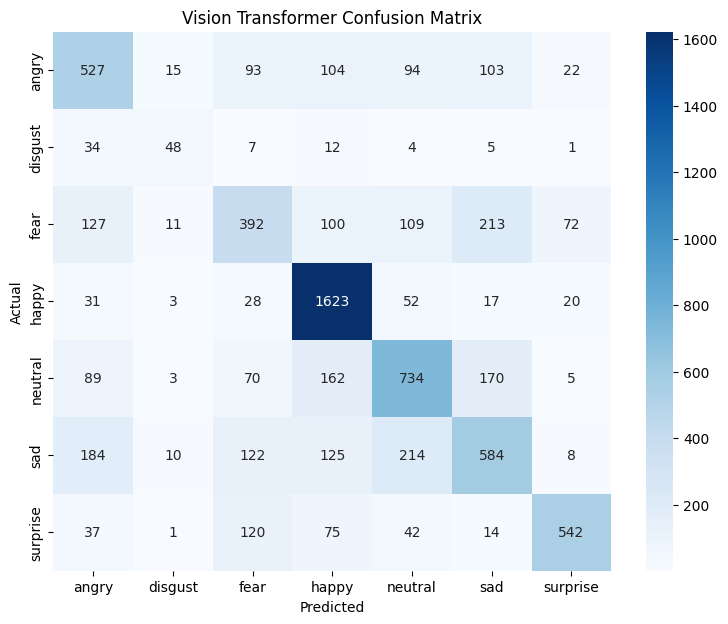

In [29]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Vision Transformer Confusion Matrix")

plt.show()

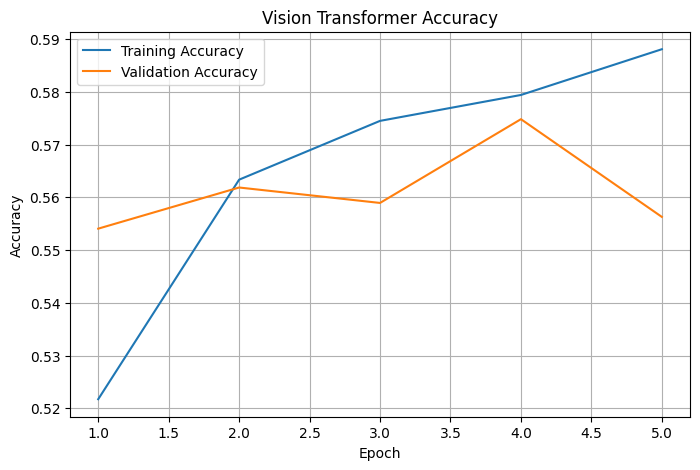

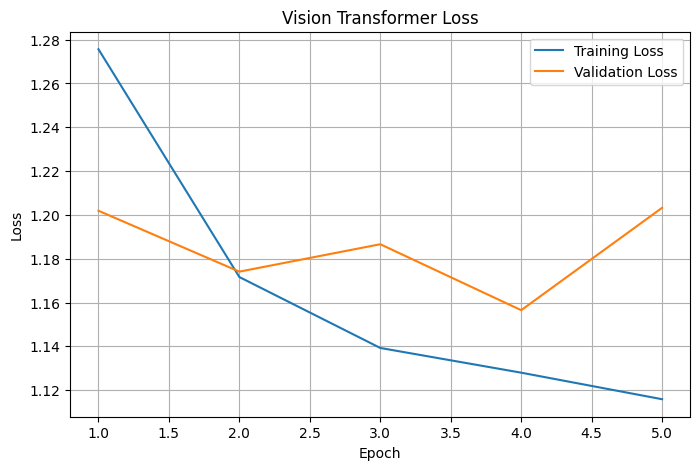

In [30]:
# ==========================================================
# Accuracy & Loss Curves
# ==========================================================

train_acc = history["train_acc"] + history_ft["train_acc"]
val_acc = history["val_acc"] + history_ft["val_acc"]

train_loss = history["train_loss"] + history_ft["train_loss"]
val_loss = history["val_loss"] + history_ft["val_loss"]

epochs = range(1,len(train_acc)+1)

# Accuracy

plt.figure(figsize=(8,5))

plt.plot(epochs,train_acc,label="Training Accuracy")
plt.plot(epochs,val_acc,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Vision Transformer Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Loss

plt.figure(figsize=(8,5))

plt.plot(epochs,train_loss,label="Training Loss")
plt.plot(epochs,val_loss,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vision Transformer Loss")

plt.legend()
plt.grid(True)

plt.show()

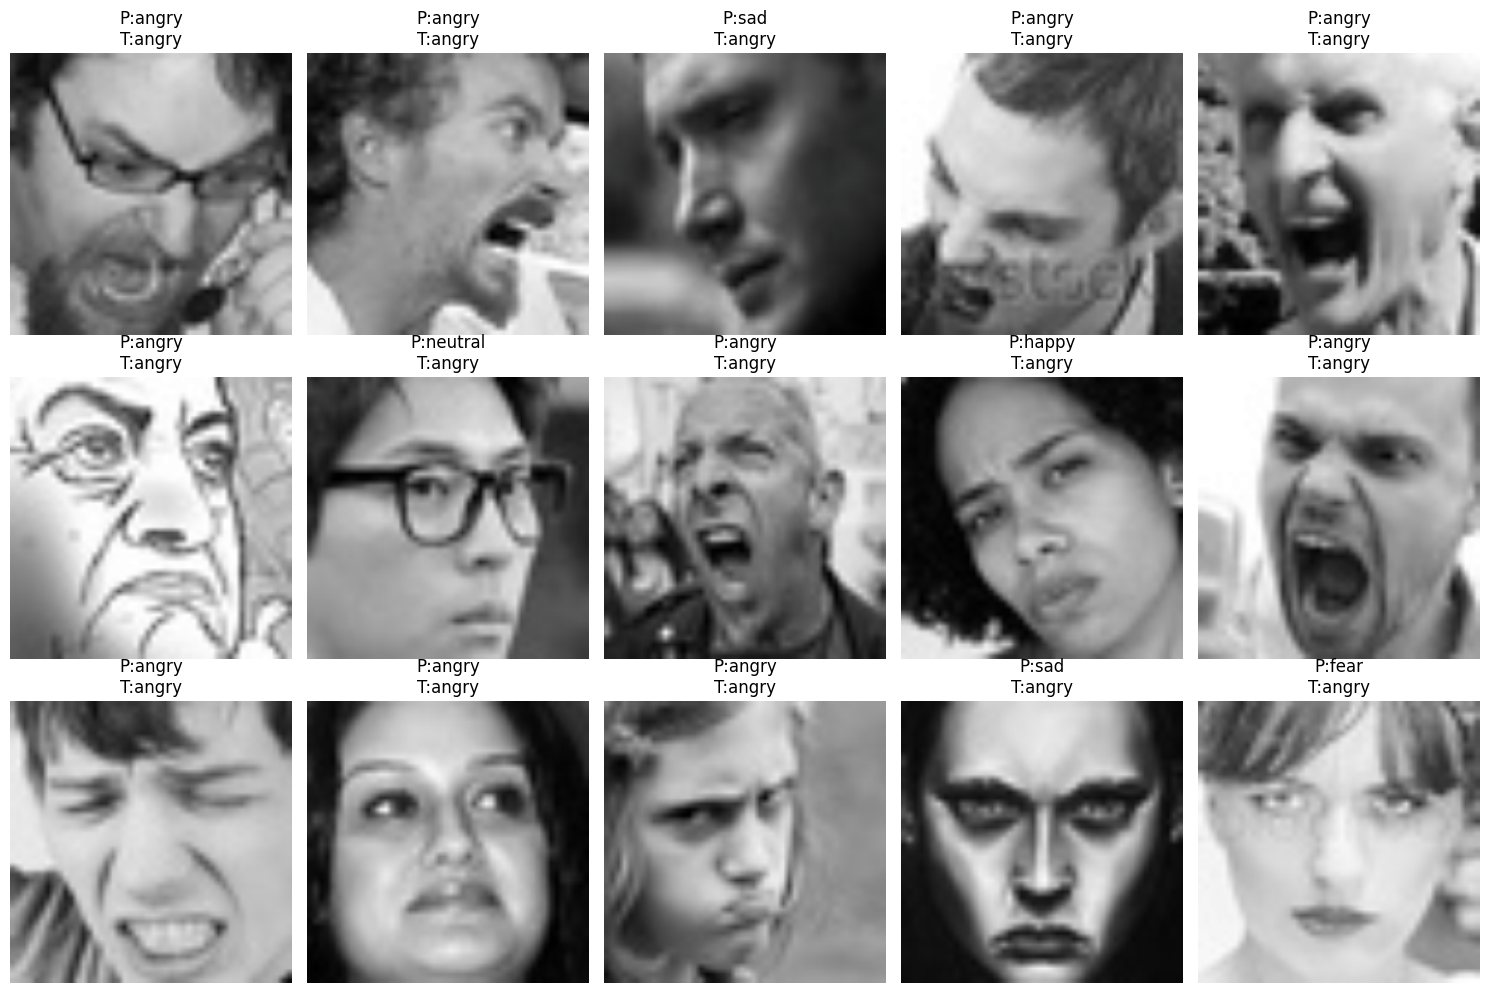

Vision Transformer model saved successfully.


In [31]:
# ==========================================================
# Sample Predictions
# ==========================================================

model.eval()

images,labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

_,preds = torch.max(outputs,1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

plt.figure(figsize=(15,10))

for i in range(15):

    img = images[i]*std + mean
    img = img.permute(1,2,0)

    plt.subplot(3,5,i+1)

    plt.imshow(img)

    plt.title(
        f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# Save Model
# ==========================================================

torch.save(model.state_dict(),"vit_model.pth")

print("Vision Transformer model saved successfully.")